In [1]:
!pip install -q transformers datasets evaluate sacrebleu sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [14]:
# Load the English–Ekegusii parallel corpus
df = pd.read_csv("/content/drive/MyDrive/_PSA_EnGuz.csv")

# Display first 5 rows
df.head()

,PSA_Id,Domain,en,guz
0,1,Education,Introduces a multimodal AI pipeline that proce...,Agochakia omoroberio bwegekoreri kia bono kiob...
1,2,Education,"[4Ts Initiative] Track, Trace, Talk, and reTur...",Omoroberio omuya nebitamboero biabekirwe gokon...
2,3,Education,[CBC Implementation] Official implementation o...,Omoroberio bweserikari okebetererio abana baso...
3,4,Education,[DigiSchool Project] Connected 21 schools to t...,Omoroberio bweserikari korenta etekinorochia a...
4,5,Education,[Digital Learning Initiative] Government rollo...,(Amasomo Abosa) Eserikari nesegerete amosomo a...


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

Dataset Shape: (4818, 4)

Columns:
Index(['PSA_Id', 'Domain', 'en', 'guz'], dtype='object')

Data Types:
PSA_Id     int64
Domain    object
en        object
guz       object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4818 entries, 0 to 4817
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   PSA_Id  4818 non-null   int64 
 1   Domain  4818 non-null   object
 2   en      4818 non-null   object
 3   guz     4818 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.7+ KB


In [16]:
print(df.isnull().sum())

PSA_Id    0
Domain    0
en        0
guz       0
dtype: int64


In [25]:
print(df[["en_length", "guz_length"]].describe())

         en_length   guz_length
count  4818.000000  4818.000000
mean     17.048360    19.660025
std       9.414979     9.549942
min       1.000000     2.000000
25%      11.000000    13.000000
50%      15.000000    18.000000
75%      21.000000    24.000000
max     109.000000    95.000000


In [17]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [18]:
print(df.columns.tolist())

['PSA_Id', 'Domain', 'en', 'guz']


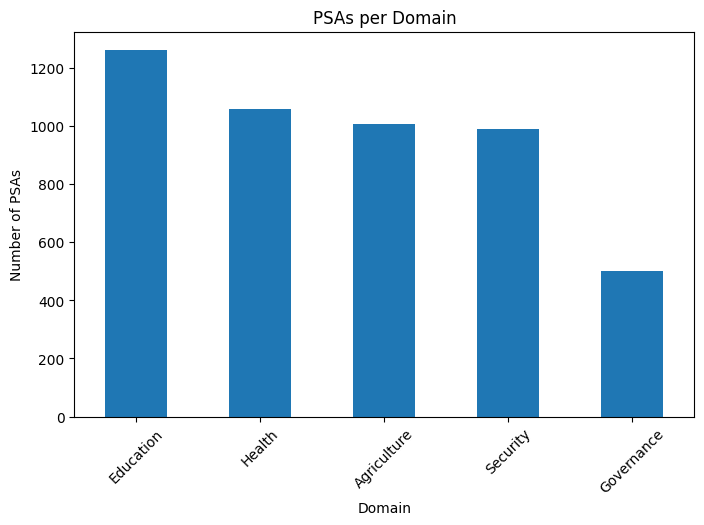

In [20]:
domain_counts = df["Domain"].value_counts()

domain_counts.plot(kind="bar", figsize=(8,5))

plt.title("PSAs per Domain")
plt.xlabel("Domain")
plt.ylabel("Number of PSAs")
plt.xticks(rotation=45)

plt.show()

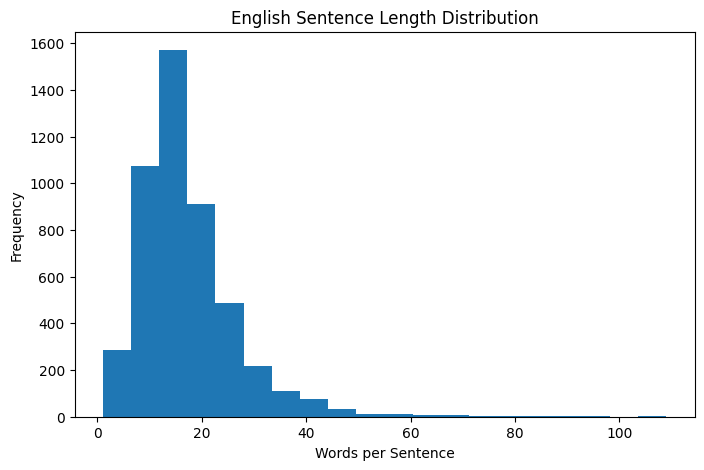

In [21]:
df["en_length"] = df["en"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.hist(df["en_length"], bins=20)

plt.title("English Sentence Length Distribution")
plt.xlabel("Words per Sentence")
plt.ylabel("Frequency")

plt.show()

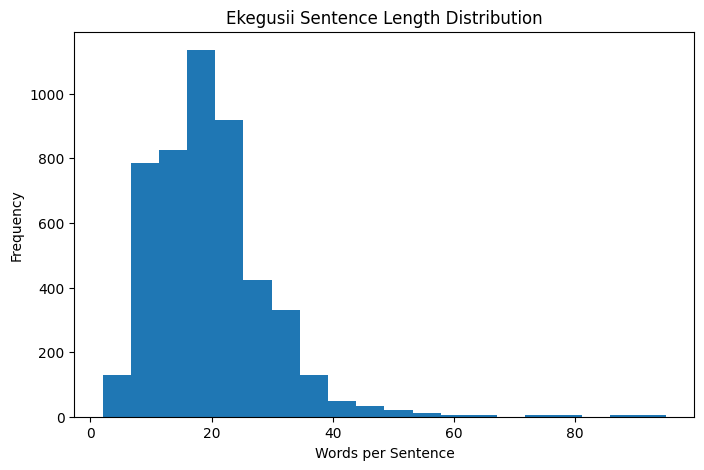

In [22]:
df["guz_length"] = df["guz"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.hist(df["guz_length"], bins=20)

plt.title("Ekegusii Sentence Length Distribution")
plt.xlabel("Words per Sentence")
plt.ylabel("Frequency")

plt.show()

In [23]:
english_vocab = set(" ".join(df["en"].astype(str)).split())
ekegusii_vocab = set(" ".join(df["guz"].astype(str)).split())

print("English Vocabulary Size:", len(english_vocab))
print("Ekegusii Vocabulary Size:", len(ekegusii_vocab))

English Vocabulary Size: 14684
Ekegusii Vocabulary Size: 19465


In [24]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

Train: (3854, 6)
Validation: (482, 6)
Test: (482, 6)


- The English–Ekegusii parallel corpus consists of 4,818 aligned PSA sentence pairs with four columns: PSA_Id, Domain, en, and guz.
- Initial data quality assessment showed no missing values across any column.
- Domain distribution and sentence-length analyses were performed to evaluate the balance and characteristics of the dataset. - Vocabulary statistics were computed for both English and Ekegusii, and the dataset was split into training (3,854 pairs), validation (482 pairs), and test (482 pairs) sets using an 80:10:10 ratio to support subsequent model training and evaluation.